In [1]:
import cellpose.core
import time, os, sys
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
mpl.rcParams['figure.dpi'] = 300
from cellpose import utils, io
from cellpose import models, io
import cellpose
# import btrack
import pandas as pd
import numpy as np
from skimage.io import imread
from cellpose import plot
from scipy.signal import savgol_filter
from scipy.optimize import linear_sum_assignment
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

from scipy.spatial.distance import cdist
from scipy.signal import savgol_filter
import imageio
import warnings
from scipy.optimize import curve_fit
from skimage.measure import regionprops
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, deque
from collections import Counter



plt.rcParams["figure.figsize"] = (3,3)
plt.rcParams["figure.dpi"] = 100

warnings.filterwarnings("ignore", category=DeprecationWarning)
%matplotlib inline

In [2]:

# --- Build the lineage graph (same as before) ---
def build_lineage_graph(tracks):
    G = nx.DiGraph()
    for t in tracks:
        c_label = int(t['curr_frame_label'])
        f = int(t['frame'])
        G.add_node((c_label, f), label=c_label, frame=f)

        p_label = t['prev_frame_label']
        if p_label is not None:
            p_label = int(p_label)
            G.add_node((p_label, f-1), label=p_label, frame=f-1)
            G.add_edge((p_label, f-1), (c_label, f))
    return G

# --- Split into trees (one per root) ---
def lineage_forest(G):
    roots = [n for n in G.nodes if G.in_degree(n) == 0]
    # Extract a weakly-connected component around each root as a tree
    # (Graph is a DAG by construction.)
    trees = []
    seen = set()
    for r in roots:
        comp = set(nx.descendants(G, r)) | {r}
        # Avoid duplicates if multiple roots share descendants (shouldn't happen)
        if comp & seen:
            continue
        seen |= comp
        T = G.subgraph(comp).copy()
        trees.append((r, T))
    return trees

# --- Compute generations (depth) from the root ---
def generations_from_root(T, root):
    depth = {root: 0}
    q = deque([root])
    while q:
        u = q.popleft()
        for v in T.successors(u):
            depth[v] = depth[u] + 1
            q.append(v)
    return depth

# --- Tidy tree layout (DFS order -> x positions; depth -> y positions) ---
def tidy_tree_layout(T, root, y_gap=1.5, x_gap=1.0):
    """
    Returns a dict pos[(label, frame)] = (x, y) with root at top, children below.
    x positions assigned by DFS leaf-order (compact, non-overlapping).
    """
    depth = generations_from_root(T, root)

    children = {u: sorted(list(T.successors(u)), key=lambda v: (depth[v], T.nodes[v]['label'], v))
                for u in T.nodes}
    # Order nodes by frame then label for consistent traversal
    for u in children:
        children[u].sort(key=lambda v: (depth[v], T.nodes[v]['frame'], T.nodes[v]['label']))

    pos = {}
    x_counter = [0]  # mutable counter captured by closure

    def assign_x(u):
        # Leaf -> get next x slot
        if len(children[u]) == 0:
            x = x_counter[0]
            x_counter[0] += 1
            return x
        # Internal: average of children's x
        xs = [assign_x(v) for v in children[u]]
        return sum(xs) / len(xs)

    # First pass to get root x (and implicitly all children)
    root_x = assign_x(root)

    # Second pass to collect all x (re-run but record)
    x_counter[0] = 0
    x_map = {}

    def place(u):
        if len(children[u]) == 0:
            x = x_counter[0]
            x_counter[0] += 1
        else:
            xs = []
            for v in children[u]:
                xs.append(place(v))
            x = sum(xs) / len(xs)
        x_map[u] = x
        return x

    place(root)

    # Scale and set y by generation (root on top: smallest y)
    for u, x in x_map.items():
        y = -depth[u] * y_gap  # downward
        pos[u] = (x * x_gap, y)

    return pos

# --- Plot a forest as stacked trees ---
def plot_lineage_as_trees(tracks, node_size=600, with_labels=True, figsize=(20, 10), tree_gap=5.0):
    G = build_lineage_graph(tracks)
    if G.number_of_nodes() == 0:
        print("No nodes to plot.")
        return

    forest = lineage_forest(G)
    if not forest:
        print("No roots found; cannot render trees.")
        return

    # Build combined positions, offsetting each tree horizontally
    combined_pos = {}
    x_offset = 1.0
    all_edges = []
    all_nodes = set()

    for root, T in forest:
        pos = tidy_tree_layout(T, root)
        # shift x by current offset
        shifted = {n: (p[0] + x_offset, p[1]) for n, p in pos.items()}
        combined_pos.update(shifted)

        all_edges.extend(list(T.edges()))
        all_nodes |= set(T.nodes())

        # compute width of this tree to set the next offset
        xs = [p[0] for p in pos.values()]
        width = (max(xs) - min(xs)) if xs else 0.0
        x_offset += width + tree_gap

#     # Draw
#     plt.figure(figsize=figsize)
#     nx.draw_networkx_edges(G, combined_pos, edgelist=all_edges, width=1)
#     nx.draw_networkx_nodes(G, combined_pos, nodelist=list(all_nodes), node_size=node_size)
#     if with_labels:
#         labels = {n: G.nodes[n]['label'] for n in all_nodes}
#         nx.draw_networkx_labels(G, combined_pos, labels=labels, font_size=8)

#     plt.axis('off')
#     plt.title("Lineage Trees (root at top)")
#     plt.tight_layout()
#     plt.show()

    return G

In [3]:
def extract_run_analysis(directory,prefx,s,d,tmax):

    img_stack=[]
    files=os.listdir(directory)
    for i in range(1,tmax):
        file_loc=directory+prefx+"_s"+str(s)+"_t"+str(i)+".TIF"
        img_stack.append(imread(file_loc).astype('int16'))

    file = np.stack(img_stack)

    num_cells=[]
    masks=[]
    for i in range(len(file)):
        masks_zero, flows, diams = model.eval(file[i], diameter=50)
        num_cells.append(masks_zero.max())
        masks.append(masks_zero)
        
    masks_arr=np.array(masks)[:,0:1120,0:1120]
    
    na=[]
    nc=[]
    for j in range(int(masks_arr.shape[1]/d)):
        for k in range(int(masks_arr.shape[2]/d)):
            sub_mask=masks_arr[:,(d*j):d*(j+1),(d*k):d*(k+1)]
            na.append(track_sub_mask(sub_mask[0:tmax,:,:],50,10)[0])
            nc.append(track_sub_mask(sub_mask[0:tmax,:,:],50,10)[1])

    n_arr=np.nansum(na)
    n_cells=np.nansum(nc)
    return n_arr/n_cells

In [4]:
def track_sub_mask(sub_mask_input,dist_thresh,pen_child):

    
    all_properties = []
    for frame_idx, mask in enumerate(sub_mask_input):
        properties = regionprops(mask)
        for prop in properties:
            all_properties.append({
                'frame': frame_idx,
                'label': prop.label,
                'centroid': prop.centroid,
                'area': prop.area,
                'bbox': prop.bbox,
                'radius': prop.feret_diameter_max
            })

    properties_df = pd.DataFrame(all_properties)

    tracks = []

    distance_threshold = dist_thresh         # pixels: cap/clip costs for implausible links
    L = 2                           # max children per parent (L=2 for binary division)
    lam_extra_child = pen_child         # penalty for each extra child (beyond first) per parent
    alpha_disappear = 100.0          # penalty if a parent uses its (i,1) dummy (i.e., disappears)
    beta_birth = 100.0               # penalty to explain a child as a "new birth"
    large_cost = 1e6      # sentinel for impossible matches

    if ('frame' in properties_df.columns):
    
        for i in range(1, len(sub_mask_input)):
            prev_frame_props = properties_df[properties_df['frame'] == i - 1].reset_index(drop=True)
            curr_frame_props = properties_df[properties_df['frame'] == i].reset_index(drop=True)
    
            if curr_frame_props.empty:
                continue
    
            if prev_frame_props.empty:
                for _, row in curr_frame_props.iterrows():
                    tracks.append({'prev_frame_label': None, 'curr_frame_label': row['label'], 'frame': i})
                continue
    
            prev_centroids = np.vstack(prev_frame_props['centroid'].to_numpy())
            curr_centroids = np.vstack(curr_frame_props['centroid'].to_numpy())
            base_D = cdist(prev_centroids, curr_centroids)  # shape m x n
    
            base_D = np.where(base_D <= distance_threshold, base_D, large_cost)
    
            m = prev_frame_props.shape[0]
            n = curr_frame_props.shape[0]
    
    
            num_rows = m * L + n
            num_cols = n + m * L
            assert num_rows == num_cols, "Matrix should be square"
    
            C = np.full((num_rows, num_cols), large_cost, dtype=float)
    
            def row_is_parent(r): return r < m * L
            def parent_idx(r):     return r // L
            def cap_slot(r):       return (r % L) + 1  # 1..L
    
            def col_is_child(c):   return c < n
            # capacity dummies are columns [n .. n + m*L - 1]
            def dummy_col_for(parent_r): return n + parent_r  # one dummy per capacity row
    
            for r in range(m * L):
                i_parent = parent_idx(r)
                ell = cap_slot(r)
                extra = 0.0 if ell == 1 else lam_extra_child
                C[r, :n] = base_D[i_parent, :] + extra
    
                dc = dummy_col_for(r)
    
                C[r, dc] = alpha_disappear if ell == 1 else 0.0
    
            for b in range(n):
                r = m * L + b  # birth row index
                C[r, :n] = beta_birth
                C[r, n:] = 0.0
    
            row_ind, col_ind = linear_sum_assignment(C)
    
            children_per_parent = {int(prev_frame_props.iloc[p]['label']): 0 for p in range(m)}
    
            child_labels = curr_frame_props['label'].to_numpy()
            parent_labels = prev_frame_props['label'].to_numpy()
    
            for r, c in zip(row_ind, col_ind):
                if row_is_parent(r) and col_is_child(c):
                    i_parent = parent_idx(r)
                    p_label = int(parent_labels[i_parent])
                    c_label = int(child_labels[c])
                    # If cost was large (distance > threshold), skip (treat as not a valid link)
                    if C[r, c] >= large_cost * 0.5:
                        continue
                    tracks.append({'prev_frame_label': p_label,
                                   'curr_frame_label': c_label,
                                   'frame': i})
                    children_per_parent[p_label] += 1
                elif (not row_is_parent(r)) and col_is_child(c):
                    c_label = int(child_labels[c])
                    if C[r, c] >= large_cost * 0.5:
                        continue
                    tracks.append({'prev_frame_label': None,
                                   'curr_frame_label': c_label,
                                   'frame': i})
        
        G=plot_lineage_as_trees(tracks)
        
        # Get the lineage forest to find the roots
        growth_slope=[]
        ids=[]
        forest = lineage_forest(G)
    
        for f in forest:
    
            root, tree = f
    
            if(root[1]==0):
                # Get the generations (depth) from this root
                depths = generations_from_root(tree, root)
                ids.append(root[0])
                growth_slope.append(np.mean(np.gradient(list(Counter(depths.values()).values()),list(Counter(depths.values()).keys()))))
        
        if (len(growth_slope)!=0):
            fa=sum(np.array(growth_slope)==0)
        else: 
            fa=np.nan
        return fa,len(growth_slope)
    else: 
        return np.nan,np.nan

In [5]:
cellpose.core.use_gpu()

True

In [6]:
model = models.CellposeModel(gpu=True, model_type='cyto2')
chan = [[0,0]]

model_type argument is not used in v4.0.1+. Ignoring this argument...


In [7]:
directory="/n/murraylab/Users/pnanda/DCS/Manuscript/eDCS014_Dx_G2_Gly2_Et1/"
files=os.listdir(directory)

In [8]:
fa_vals_rep1=[]

s_rep1=np.arange(1,37,1)
t_max=np.repeat([12,24],[12,24])
for i,s in enumerate(s_rep1):
    fr_val=extract_run_analysis(directory,'yPN',s,500,t_max[i])
    print('Arrestors Fraction: ',fr_val)
    fa_vals_rep1.append(fr_val)


Arrestors Fraction:  0.8197278911564626
Arrestors Fraction:  0.8346456692913385
Arrestors Fraction:  0.835016835016835
Arrestors Fraction:  0.6532258064516129
Arrestors Fraction:  0.7741935483870968
Arrestors Fraction:  0.716374269005848
Arrestors Fraction:  0.6676056338028169
Arrestors Fraction:  0.7297297297297297
Arrestors Fraction:  0.6377952755905512
Arrestors Fraction:  0.47307692307692306
Arrestors Fraction:  0.4965034965034965
Arrestors Fraction:  0.5560538116591929
Arrestors Fraction:  0.5327868852459017
Arrestors Fraction:  0.45018450184501846
Arrestors Fraction:  0.6376811594202898
Arrestors Fraction:  0.6017699115044248
Arrestors Fraction:  0.6958174904942965
Arrestors Fraction:  0.6849593495934959
Arrestors Fraction:  0.5316455696202531
Arrestors Fraction:  0.6140350877192983
Arrestors Fraction:  0.6203208556149733
Arrestors Fraction:  0.4110169491525424
Arrestors Fraction:  0.48249027237354086
Arrestors Fraction:  0.5590551181102362
Arrestors Fraction:  0.7160804020100503

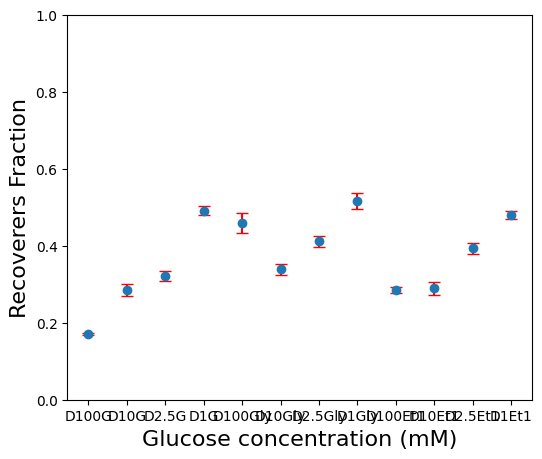

In [9]:
fa_vals_arr=np.array(fa_vals_rep1).reshape(12,3)

y = 1 - fa_vals_arr.mean(axis=1)
yerr = fa_vals_arr.std(axis=1)/3  # Example: standard deviation as error
plt.figure(figsize=(6,5))
plt.errorbar(['D100G','D10G','D2.5G','D1G','D100Gly','D10Gly','D2.5Gly','D1Gly','D100Et1','D10Et1','D2.5Et1','D1Et1'], y, yerr=yerr, fmt='o', ecolor='red', capsize=4)
plt.xlabel('Glucose concentration (mM)',fontsize=16)
plt.ylabel('Recoverers Fraction',fontsize=16)
# plt.xscale('log',base=10
plt.ylim([0,1])
plt.show()

In [10]:
fa_vals_rep2=[]

s_rep2=np.arange(37,73,1)
t_max=np.repeat([12,24],[12,24])
for i,s in enumerate(s_rep2):
    fr_val=extract_run_analysis(directory,'yPN',s,500,t_max[i])
    print('Arrestors Fraction: ',fr_val)
    fa_vals_rep2.append(fr_val)


Arrestors Fraction:  0.8104089219330854
Arrestors Fraction:  0.8032786885245902
Arrestors Fraction:  0.8203592814371258
Arrestors Fraction:  0.8104838709677419
Arrestors Fraction:  0.7386363636363636
Arrestors Fraction:  0.7763975155279503
Arrestors Fraction:  0.6797583081570997
Arrestors Fraction:  0.6327160493827161
Arrestors Fraction:  0.6677740863787376
Arrestors Fraction:  0.46973365617433416
Arrestors Fraction:  0.52734375
Arrestors Fraction:  0.4957081545064378
Arrestors Fraction:  0.6305084745762712
Arrestors Fraction:  0.624561403508772
Arrestors Fraction:  0.6166666666666667
Arrestors Fraction:  0.6610169491525424
Arrestors Fraction:  0.6578171091445427
Arrestors Fraction:  0.6546762589928058
Arrestors Fraction:  0.6007462686567164
Arrestors Fraction:  0.5625
Arrestors Fraction:  0.642023346303502
Arrestors Fraction:  0.5363128491620112
Arrestors Fraction:  0.5226480836236934
Arrestors Fraction:  0.514018691588785
Arrestors Fraction:  0.743142144638404
Arrestors Fraction:  0.

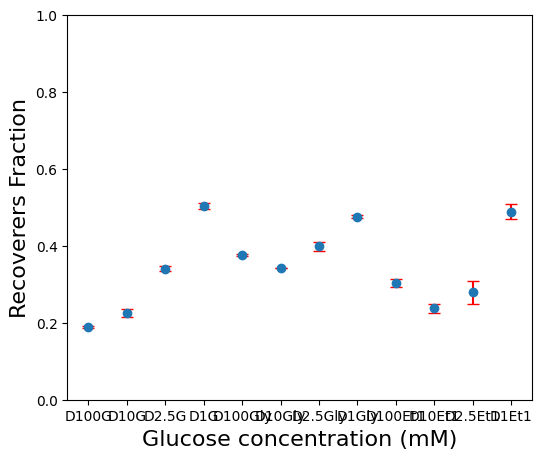

In [11]:
fa_vals_arr=np.array(fa_vals_rep2).reshape(12,3)

y = 1 - fa_vals_arr.mean(axis=1)
yerr = fa_vals_arr.std(axis=1)/3  # Example: standard deviation as error
plt.figure(figsize=(6,5))
plt.errorbar(['D100G','D10G','D2.5G','D1G','D100Gly','D10Gly','D2.5Gly','D1Gly','D100Et1','D10Et1','D2.5Et1','D1Et1'], y, yerr=yerr, fmt='o', ecolor='red', capsize=4)
plt.xlabel('Glucose concentration (mM)',fontsize=16)
plt.ylabel('Recoverers Fraction',fontsize=16)
# plt.xscale('log',base=10
plt.ylim([0,1])
plt.show()

In [12]:
fa_vals_rep3=[]

s_rep3=np.arange(73,109,1)
t_max=np.repeat([12,24],[12,24])
for i,s in enumerate(s_rep3):
    fr_val=extract_run_analysis(directory,'yPN',s,500,t_max[i])
    print('Arrestors Fraction: ',fr_val)
    fa_vals_rep3.append(fr_val)


Arrestors Fraction:  0.695067264573991
Arrestors Fraction:  0.7491638795986622
Arrestors Fraction:  0.8076923076923077
Arrestors Fraction:  0.8026905829596412
Arrestors Fraction:  0.7698412698412699
Arrestors Fraction:  0.8189300411522634
Arrestors Fraction:  0.6866952789699571
Arrestors Fraction:  0.6893617021276596
Arrestors Fraction:  0.7872340425531915
Arrestors Fraction:  0.5641025641025641
Arrestors Fraction:  0.5912408759124088
Arrestors Fraction:  0.5334872979214781
Arrestors Fraction:  0.7159090909090909
Arrestors Fraction:  0.62
Arrestors Fraction:  0.688953488372093
Arrestors Fraction:  0.6869918699186992
Arrestors Fraction:  0.6457765667574932
Arrestors Fraction:  0.7108843537414966
Arrestors Fraction:  0.7181467181467182
Arrestors Fraction:  0.7172774869109948
Arrestors Fraction:  0.6616161616161617
Arrestors Fraction:  0.5378486055776892
Arrestors Fraction:  0.5372549019607843
Arrestors Fraction:  0.4583333333333333
Arrestors Fraction:  0.7457044673539519
Arrestors Fracti

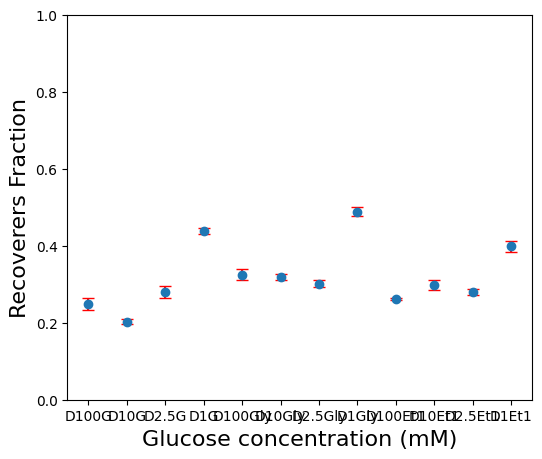

In [13]:
fa_vals_arr=np.array(fa_vals_rep3).reshape(12,3)

y = 1 - fa_vals_arr.mean(axis=1)
yerr = fa_vals_arr.std(axis=1)/3  # Example: standard deviation as error
plt.figure(figsize=(6,5))
plt.errorbar(['D100G','D10G','D2.5G','D1G','D100Gly','D10Gly','D2.5Gly','D1Gly','D100Et1','D10Et1','D2.5Et1','D1Et1'], y, yerr=yerr, fmt='o', ecolor='red', capsize=4)
plt.xlabel('Glucose concentration (mM)',fontsize=16)
plt.ylabel('Recoverers Fraction',fontsize=16)
# plt.xscale('log',base=10
plt.ylim([0,1])
plt.show()

In [16]:
fa_vals_arr_save=np.array([fa_vals_arr1,fa_vals_arr2,fa_vals_arr3])
np.save('gal_eth_fr',fa_vals_arr_save)

In [25]:
fa_vals_arr_raw=np.load('gal_eth_fr.npy')

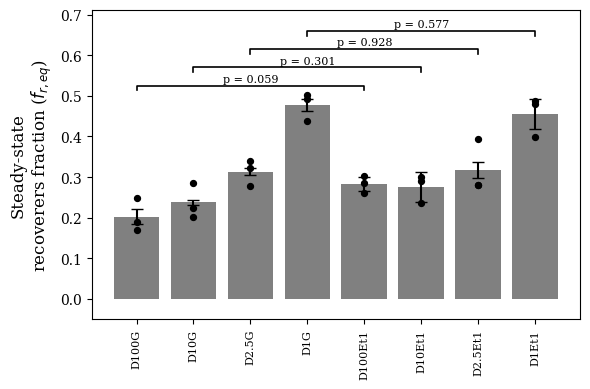

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fa_vals_arr1=fa_vals_arr_raw[0]
fa_vals_arr2=fa_vals_arr_raw[1]
fa_vals_arr3=fa_vals_arr_raw[2]

fa_vals_arr=np.mean(fa_vals_arr_raw,axis=0)

x = ['D100G','D10G','D2.5G','D1G','D100Et1','D10Et1','D2.5Et1','D1Et1']
y = (1 - fa_vals_arr).mean(axis=1)
yerr = (1 - fa_vals_arr).std(axis=1)

rec1 = 1 - fa_vals_arr1.mean(axis=1)
rec2 = 1 - fa_vals_arr2.mean(axis=1)
rec3 = 1 - fa_vals_arr3.mean(axis=1)
rec_all = np.vstack([rec1, rec2, rec3]).T  # shape (8,3)

dose_pairs = [
    (0, 4, 'D100'),
    (1, 5, 'D10'),
    (2, 6, 'D2.5'),
    (3, 7, 'D1'),
]

def add_sig_bar(ax, x1, x2, y, h=0.012, text='p=0.05'):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], c='k', lw=1.2, clip_on=False)
    ax.text((x1+x2)/2, y+h+0.004, text, ha='center', va='bottom', fontsize=8, clip_on=False)

plt.rc('font', family='serif')
fig, ax = plt.subplots(figsize=(6,4))

pos = np.arange(len(x))

ax.bar(pos, y, yerr=yerr, color='gray', linewidth=2, capsize=4)
ax.scatter(pos, rec1, color='k', s=18, zorder=3)
ax.scatter(pos, rec2, color='k', s=18, zorder=3)
ax.scatter(pos, rec3, color='k', s=18, zorder=3)

ax.set_ylabel(r'Steady-state' + '\n' + r'recoverers fraction ($f_{r,eq}$)', fontsize=12)
ax.set_xticks(pos)
ax.set_xticklabels(x, fontsize=8, rotation=90)

y_max = np.max(y + yerr)
base = y_max + 0.02
step = 0.045
h = 0.012

for k, (i, j, label) in enumerate(dose_pairs):
    _, p = stats.ttest_ind(rec_all[i], rec_all[j], equal_var=False)
    # format p however you like:
    if p < 1e-3:
        text = f"p = {p:.1e}"
    else:
        text = f"p = {p:.3f}"
    y_bar = base + k*step
    add_sig_bar(ax, i, j, y_bar, h=h, text=text)

# critical fix: expand ylim so annotation bars are inside the plot
top_needed = base + (len(dose_pairs)-1)*step + h + 0.05
ax.set_ylim(-0.05, top_needed)

fig.tight_layout()
plt.savefig("Fraction_Invariance_G2_Et1_dose_pairs_sigbars_pvals.png", dpi=600, bbox_inches='tight')
plt.show()

In [17]:
fa_vals_arr_raw=np.load('glucose_gradient_full_data.npy')[:,[0,2,4,6]]

In [18]:
fa_vals_arr_raw.shape 

(3, 4, 3)

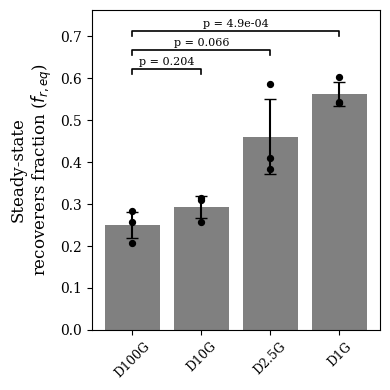

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# fa_vals_arr_raw: shape (3, 4, 3)
fa_vals_arr1 = fa_vals_arr_raw[0]
fa_vals_arr2 = fa_vals_arr_raw[1]
fa_vals_arr3 = fa_vals_arr_raw[2]

# per‑condition recoverer fraction (mean across timepoints)
rec1 = 1 - fa_vals_arr1.mean(axis=1)  # (4,)
rec2 = 1 - fa_vals_arr2.mean(axis=1)  # (4,)
rec3 = 1 - fa_vals_arr3.mean(axis=1)  # (4,)

# stack replicates: shape (4,3) = doses × replicates
rec_all = np.vstack([rec1, rec2, rec3]).T

# mean ± SD across replicates (for bars)
y    = rec_all.mean(axis=1)  # (4,)
yerr = rec_all.std(axis=1)   # (4,)

x = ['D100G', 'D10G', 'D2.5G', 'D1G']

# compare all doses to D100G (index 0)
dose_pairs = [
    (0, 1, 'D100G vs D10G'),
    (0, 2, 'D100G vs D2.5G'),
    (0, 3, 'D100G vs D1G'),
]

def add_sig_bar(ax, x1, x2, y, h=0.012, text='p=0.05'):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y],
            c='k', lw=1.2, clip_on=False)
    ax.text((x1+x2)/2, y+h+0.004, text,
            ha='center', va='bottom', fontsize=8, clip_on=False)

plt.rc('font', family='serif')
fig, ax = plt.subplots(figsize=(4,4))

pos = np.arange(len(x))

# bar: mean ± SD
ax.bar(pos, y, yerr=yerr, color='gray', linewidth=1.5, capsize=4)

# overlaid points for each replicate
ax.scatter(pos, rec1, color='k', s=18, zorder=3)
ax.scatter(pos, rec2, color='k', s=18, zorder=3)
ax.scatter(pos, rec3, color='k', s=18, zorder=3)

ax.set_ylabel(r'Steady-state' + '\n' + r'recoverers fraction ($f_{r,eq}$)', fontsize=12)
ax.set_xticks(pos)
ax.set_xticklabels(x, fontsize=9, rotation=45)

# set ylim and draw sig bars
y_max = np.max(y + yerr)
base = y_max + 0.02
step = 0.045
h = 0.012

for k, (i, j, label) in enumerate(dose_pairs):
    # Welch's t‑test on replicates for dose i vs j
    _, p = stats.ttest_ind(rec_all[i], rec_all[j], equal_var=False)
    if p < 1e-3:
        text = f"p = {p:.1e}"
    else:
        text = f"p = {p:.3f}"
    y_bar = base + k*step
    add_sig_bar(ax, i, j, y_bar, h=h, text=text)

top_needed = base + (len(dose_pairs)-1)*step + h + 0.05
ax.set_ylim(0, top_needed)

fig.tight_layout()
plt.savefig("Fraction_Invariance_G2_glucose_only_sigbars_vs_D100G.png",
            dpi=600, bbox_inches='tight')
plt.show()